# Student Performance & Learning Analytics

## 1. Project Objective
## 2. Import Libraries
## 3. Load Dataset
## 4. Data Understanding
## 5. Data Cleaning
## 6. Exploratory Data Analysis
## 7. Attendance Analysis
## 8. Subject-wise Performance
## 9. Correlation Analysis
## 10. Feature Engineering
## 11. Conclusion

In [3]:
import pandas as pd
import numpy as np

# For reproducible results
np.random.seed(42)

# Number of students
n = 500

# Create student dataset
df = pd.DataFrame({
    "Student_ID": range(1, n + 1),
    "Gender": np.random.choice(["Male", "Female"], n),
    "Age": np.random.randint(17, 23, n),
    "Study_Hours": np.round(np.random.uniform(1, 10, n), 1),
    "Attendance": np.round(np.random.uniform(50, 100, n), 1),
    "Math_Score": np.random.randint(35, 101, n),
    "Science_Score": np.random.randint(35, 101, n),
    "English_Score": np.random.randint(35, 101, n),
    "Previous_Score": np.random.randint(35, 101, n)
})

# Generate Final Score based partly on other factors
df["Final_Score"] = (
    0.30 * df["Math_Score"] +
    0.25 * df["Science_Score"] +
    0.20 * df["English_Score"] +
    0.10 * df["Previous_Score"] +
    0.10 * df["Attendance"] +
    0.05 * (df["Study_Hours"] * 10)
)

# Add a small amount of random variation
noise = np.random.normal(0, 4, n)

df["Final_Score"] = np.clip(
    df["Final_Score"] + noise,
    0,
    100
).round(2)

# Display first 5 rows
df.head()

,Student_ID,Gender,Age,Study_Hours,Attendance,Math_Score,Science_Score,English_Score,Previous_Score,Final_Score
0,1,Male,21,5.4,60.9,66,91,64,61,70.41
1,2,Female,21,3.3,97.5,45,100,91,46,74.93
2,3,Male,17,5.1,89.3,44,50,81,51,48.36
3,4,Male,19,9.8,54.5,91,85,69,40,75.51
4,5,Male,18,5.4,70.9,59,73,53,39,61.21


In [4]:
df.shape

(500, 10)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Student_ID      500 non-null    int64  
 1   Gender          500 non-null    object 
 2   Age             500 non-null    int64  
 3   Study_Hours     500 non-null    float64
 4   Attendance      500 non-null    float64
 5   Math_Score      500 non-null    int64  
 6   Science_Score   500 non-null    int64  
 7   English_Score   500 non-null    int64  
 8   Previous_Score  500 non-null    int64  
 9   Final_Score     500 non-null    float64
dtypes: float64(3), int64(6), object(1)
memory usage: 39.2+ KB


In [6]:
df.describe()

,Student_ID,Age,Study_Hours,Attendance,Math_Score,Science_Score,English_Score,Previous_Score,Final_Score
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.00000,500.000000
mean,250.500000,19.462000,5.294800,75.470200,65.878000,68.232000,67.734000,68.86400,67.186920
std,144.481833,1.715354,2.584836,14.637573,19.135502,18.584319,18.910591,19.17741,9.540479
min,1.000000,17.000000,1.000000,50.200000,35.000000,35.000000,35.000000,35.00000,40.960000
25%,125.750000,18.000000,3.075000,61.900000,50.000000,53.000000,51.000000,53.00000,60.440000
50%,250.500000,20.000000,5.200000,76.300000,65.000000,69.000000,68.000000,69.00000,67.810000
75%,375.250000,21.000000,7.500000,88.100000,83.000000,83.000000,85.000000,85.25000,74.355000
max,500.000000,22.000000,10.000000,100.000000,100.000000,100.000000,100.000000,100.00000,91.300000


In [7]:
df.to_csv("student_performance.csv", index=False)

print("Dataset created successfully!")

Dataset created successfully!


In [8]:
df.head()

,Student_ID,Gender,Age,Study_Hours,Attendance,Math_Score,Science_Score,English_Score,Previous_Score,Final_Score
0,1,Male,21,5.4,60.9,66,91,64,61,70.41
1,2,Female,21,3.3,97.5,45,100,91,46,74.93
2,3,Male,17,5.1,89.3,44,50,81,51,48.36
3,4,Male,19,9.8,54.5,91,85,69,40,75.51
4,5,Male,18,5.4,70.9,59,73,53,39,61.21


In [9]:
df.columns

Index(['Student_ID', 'Gender', 'Age', 'Study_Hours', 'Attendance',
       'Math_Score', 'Science_Score', 'English_Score', 'Previous_Score',
       'Final_Score'],
      dtype='object')

In [10]:
df.isnull().sum()

,0
Student_ID,0
Gender,0
Age,0
Study_Hours,0
Attendance,0
Math_Score,0
Science_Score,0
English_Score,0
Previous_Score,0
Final_Score,0


In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
print("Minimum Attendance:", df["Attendance"].min())
print("Maximum Attendance:", df["Attendance"].max())

print("Minimum Final Score:", df["Final_Score"].min())
print("Maximum Final Score:", df["Final_Score"].max())

Minimum Attendance: 50.2
Maximum Attendance: 100.0
Minimum Final Score: 40.96
Maximum Final Score: 91.3


In [13]:
df.describe()

,Student_ID,Age,Study_Hours,Attendance,Math_Score,Science_Score,English_Score,Previous_Score,Final_Score
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.00000,500.000000
mean,250.500000,19.462000,5.294800,75.470200,65.878000,68.232000,67.734000,68.86400,67.186920
std,144.481833,1.715354,2.584836,14.637573,19.135502,18.584319,18.910591,19.17741,9.540479
min,1.000000,17.000000,1.000000,50.200000,35.000000,35.000000,35.000000,35.00000,40.960000
25%,125.750000,18.000000,3.075000,61.900000,50.000000,53.000000,51.000000,53.00000,60.440000
50%,250.500000,20.000000,5.200000,76.300000,65.000000,69.000000,68.000000,69.00000,67.810000
75%,375.250000,21.000000,7.500000,88.100000,83.000000,83.000000,85.000000,85.25000,74.355000
max,500.000000,22.000000,10.000000,100.000000,100.000000,100.000000,100.000000,100.00000,91.300000


In [14]:
df["Final_Score"].mean()

np.float64(67.18692)

In [15]:
df["Attendance"].mean()

np.float64(75.4702)

In [16]:
df["Study_Hours"].mean()

np.float64(5.2947999999999995)

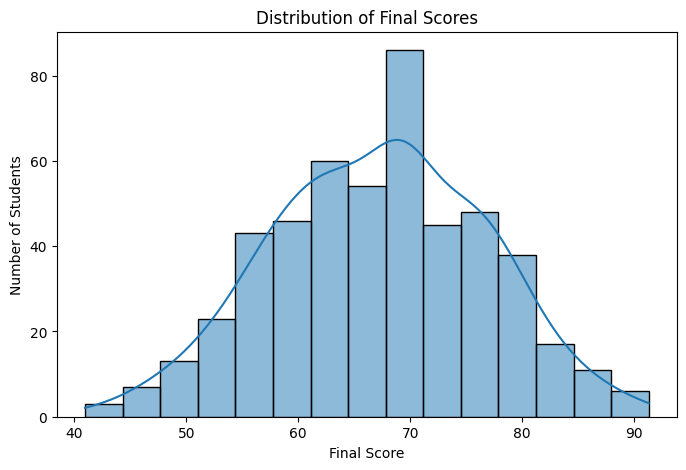

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))

sns.histplot(df["Final_Score"], bins=15, kde=True)

plt.title("Distribution of Final Scores")
plt.xlabel("Final Score")
plt.ylabel("Number of Students")

plt.show()

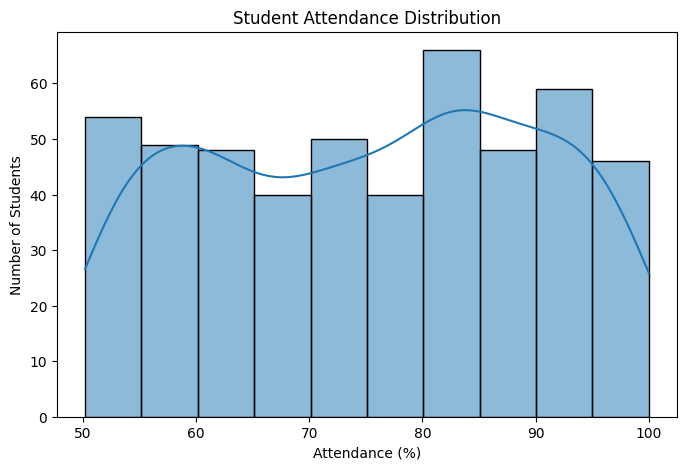

In [18]:
plt.figure(figsize=(8, 5))

sns.histplot(df["Attendance"], bins=10, kde=True)

plt.title("Student Attendance Distribution")
plt.xlabel("Attendance (%)")
plt.ylabel("Number of Students")

plt.show()

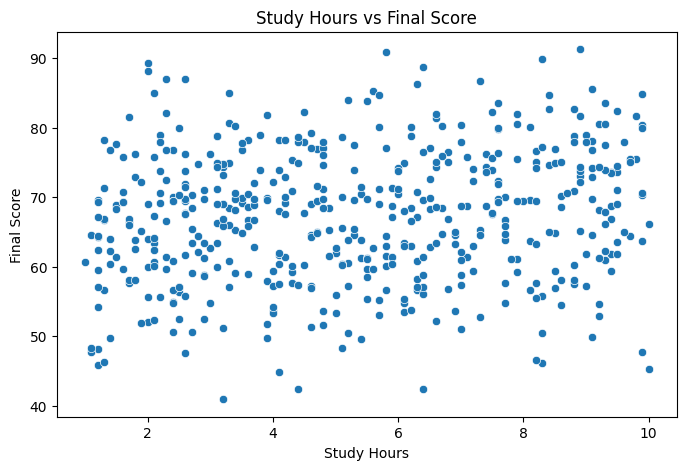

In [19]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Study_Hours",
    y="Final_Score"
)

plt.title("Study Hours vs Final Score")
plt.xlabel("Study Hours")
plt.ylabel("Final Score")

plt.show()

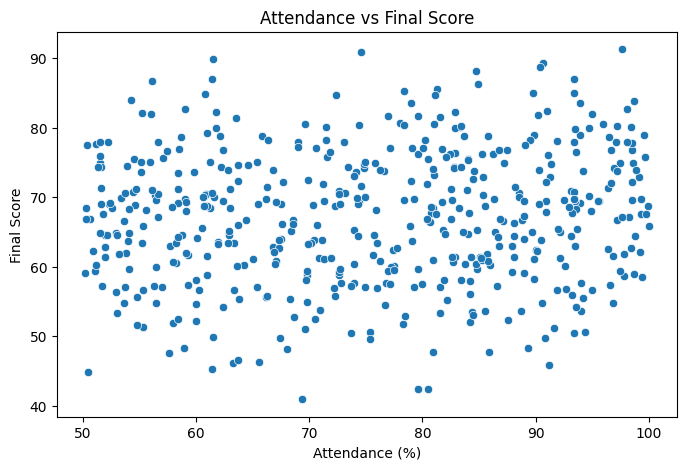

In [20]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Attendance",
    y="Final_Score"
)

plt.title("Attendance vs Final Score")
plt.xlabel("Attendance (%)")
plt.ylabel("Final Score")

plt.show()

In [21]:
subject_means = df[
    ["Math_Score", "Science_Score", "English_Score"]
].mean()

subject_means

,0
Math_Score,65.878
Science_Score,68.232
English_Score,67.734


Libraries imported successfully!

Dataset created successfully!

--- DATASET SHAPE ---
(500, 10)

--- FIRST 5 ROWS ---


,Student_ID,Gender,Age,Study_Hours,Attendance,Math_Score,Science_Score,English_Score,Previous_Score,Final_Score
0,1,Male,21,5.4,60.9,66,91,64,61,70.41
1,2,Female,21,3.3,97.5,45,100,91,46,74.93
2,3,Male,17,5.1,89.3,44,50,81,51,48.36
3,4,Male,19,9.8,54.5,91,85,69,40,75.51
4,5,Male,18,5.4,70.9,59,73,53,39,61.21



--- COLUMN INFORMATION ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Student_ID      500 non-null    int64  
 1   Gender          500 non-null    object 
 2   Age             500 non-null    int64  
 3   Study_Hours     500 non-null    float64
 4   Attendance      500 non-null    float64
 5   Math_Score      500 non-null    int64  
 6   Science_Score   500 non-null    int64  
 7   English_Score   500 non-null    int64  
 8   Previous_Score  500 non-null    int64  
 9   Final_Score     500 non-null    float64
dtypes: float64(3), int64(6), object(1)
memory usage: 39.2+ KB

--- STATISTICAL SUMMARY ---


,Student_ID,Age,Study_Hours,Attendance,Math_Score,Science_Score,English_Score,Previous_Score,Final_Score
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.00000,500.000000
mean,250.500000,19.462000,5.294800,75.470200,65.878000,68.232000,67.734000,68.86400,67.186920
std,144.481833,1.715354,2.584836,14.637573,19.135502,18.584319,18.910591,19.17741,9.540479
min,1.000000,17.000000,1.000000,50.200000,35.000000,35.000000,35.000000,35.00000,40.960000
25%,125.750000,18.000000,3.075000,61.900000,50.000000,53.000000,51.000000,53.00000,60.440000
50%,250.500000,20.000000,5.200000,76.300000,65.000000,69.000000,68.000000,69.00000,67.810000
75%,375.250000,21.000000,7.500000,88.100000,83.000000,83.000000,85.000000,85.25000,74.355000
max,500.000000,22.000000,10.000000,100.000000,100.000000,100.000000,100.000000,100.00000,91.300000



--- MISSING VALUES ---
Student_ID        0
Gender            0
Age               0
Study_Hours       0
Attendance        0
Math_Score        0
Science_Score     0
English_Score     0
Previous_Score    0
Final_Score       0
dtype: int64

--- DUPLICATES ---
0

--- INVALID VALUES ---
Attendance below 0: 0
Attendance above 100: 0
Final scores below 0: 0
Final scores above 100: 0

--- BASIC PERFORMANCE ---
Average Final Score: 67.19
Average Attendance: 75.47 %
Average Study Hours: 5.29
Highest Final Score: 91.3
Lowest Final Score: 40.96

--- SUBJECT-WISE AVERAGE ---
Math_Score       65.88
Science_Score    68.23
English_Score    67.73
dtype: float64

Highest average subject: Science_Score
Lowest average subject: Math_Score


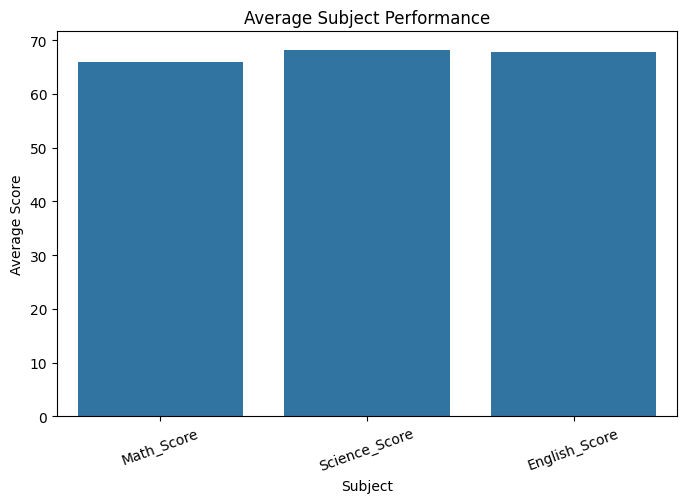

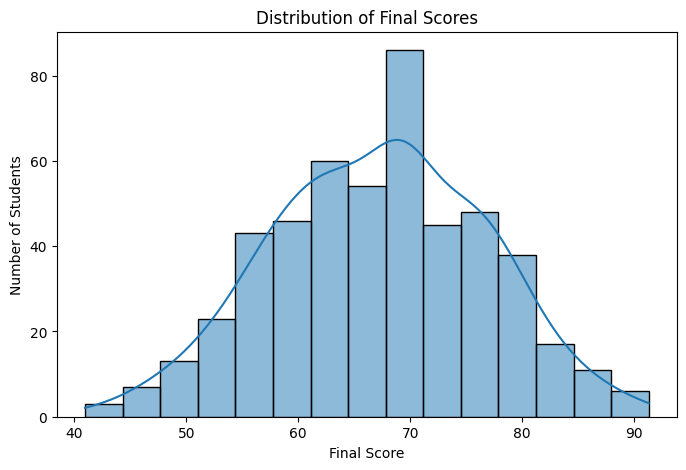

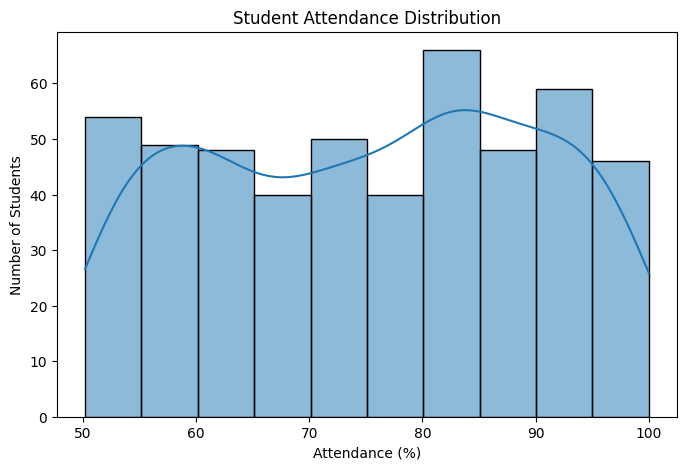

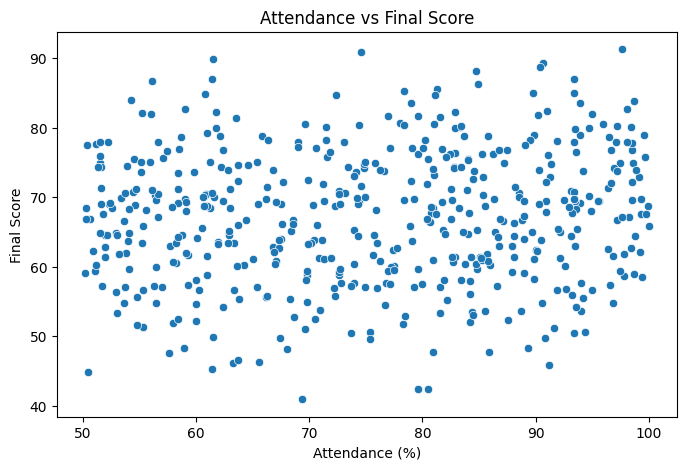

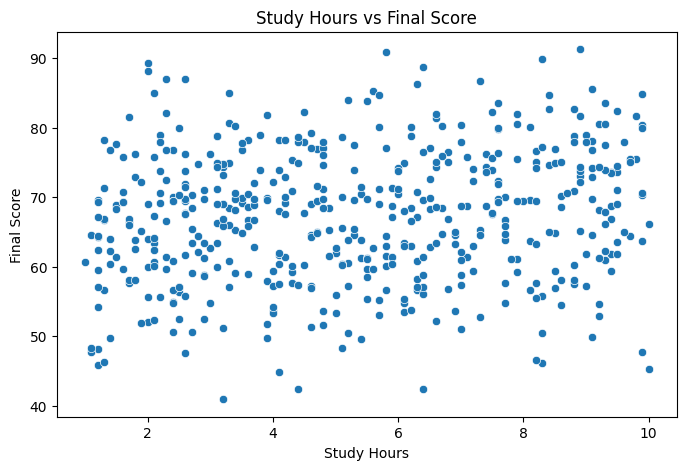


--- CORRELATION WITH FINAL SCORE ---
Attendance correlation: 0.099
Study Hours correlation: 0.154


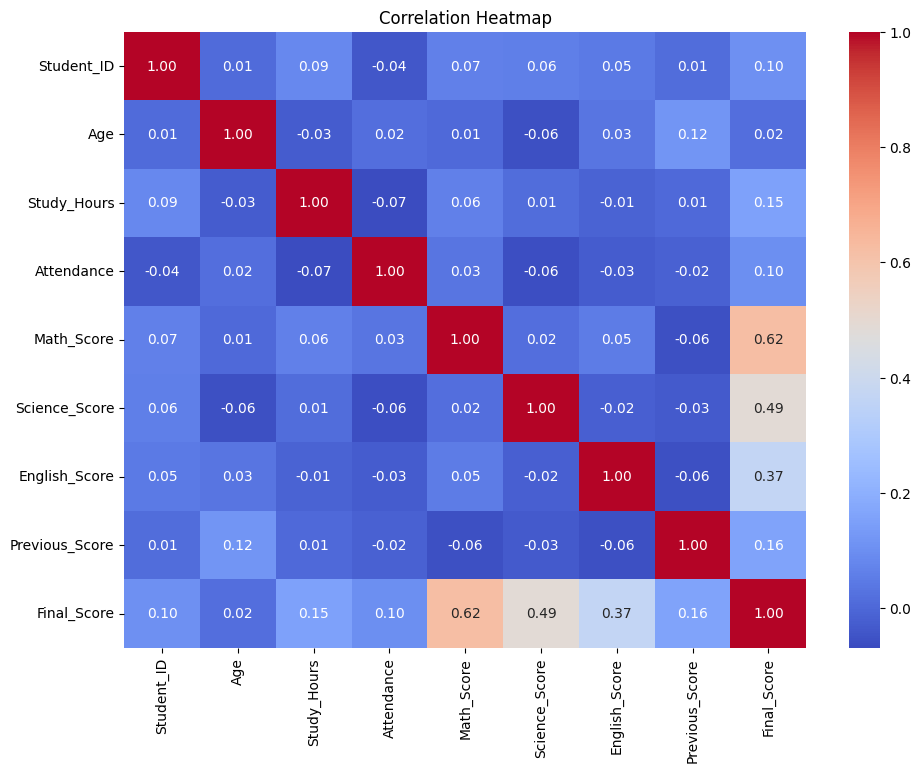


--- PERFORMANCE CATEGORIES ---
Performance_Category
Good         338
Average      117
Excellent     45
Name: count, dtype: int64


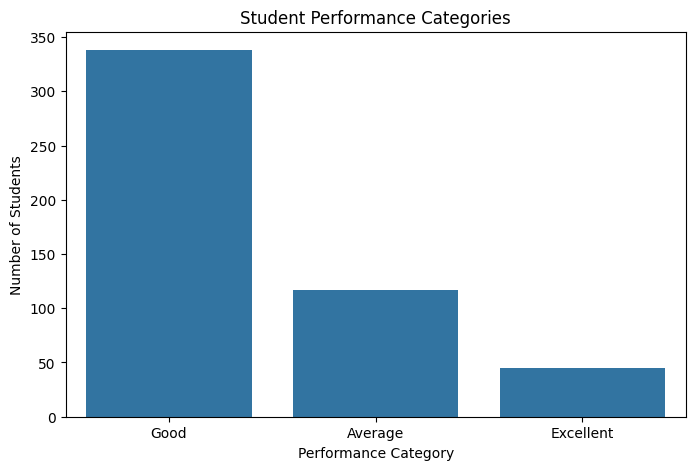


--- FINAL DATASET ---


,Student_ID,Gender,Age,Study_Hours,Attendance,Math_Score,Science_Score,English_Score,Previous_Score,Final_Score,Performance_Category,Average_Subject_Score,Attendance_Category,Study_Level
0,1,Male,21,5.4,60.9,66,91,64,61,70.41,Good,73.67,Moderate,High
1,2,Female,21,3.3,97.5,45,100,91,46,74.93,Good,78.67,Excellent,Moderate
2,3,Male,17,5.1,89.3,44,50,81,51,48.36,Average,58.33,Good,High
3,4,Male,19,9.8,54.5,91,85,69,40,75.51,Good,81.67,Low,Very High
4,5,Male,18,5.4,70.9,59,73,53,39,61.21,Good,61.67,Moderate,High



Final dataset shape: (500, 14)

Cleaned dataset saved successfully!
File: cleaned_student_performance.csv

DAY 1 COMPLETED

✓ Dataset creation
✓ Data understanding
✓ Missing-value check
✓ Duplicate check
✓ Data validation
✓ Basic statistics
✓ Subject-wise analysis
✓ Attendance analysis
✓ Study-hours analysis
✓ Performance visualization
✓ Correlation analysis
✓ Performance categories
✓ Feature engineering
✓ Cleaned dataset saved



In [22]:
# ============================================================
# STUDENT PERFORMANCE & LEARNING ANALYTICS - DAY 1
# ============================================================

# 1. IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option("display.max_columns", None)

print("Libraries imported successfully!")


# ============================================================
# 2. CREATE SYNTHETIC DATASET
# ============================================================

np.random.seed(42)

n = 500

df = pd.DataFrame({
    "Student_ID": range(1, n + 1),
    "Gender": np.random.choice(["Male", "Female"], n),
    "Age": np.random.randint(17, 23, n),
    "Study_Hours": np.round(np.random.uniform(1, 10, n), 1),
    "Attendance": np.round(np.random.uniform(50, 100, n), 1),
    "Math_Score": np.random.randint(35, 101, n),
    "Science_Score": np.random.randint(35, 101, n),
    "English_Score": np.random.randint(35, 101, n),
    "Previous_Score": np.random.randint(35, 101, n)
})

# Generate final score using academic and learning factors
df["Final_Score"] = (
    0.30 * df["Math_Score"] +
    0.25 * df["Science_Score"] +
    0.20 * df["English_Score"] +
    0.10 * df["Previous_Score"] +
    0.10 * df["Attendance"] +
    0.05 * (df["Study_Hours"] * 10)
)

# Add small random variation
noise = np.random.normal(0, 4, n)

df["Final_Score"] = np.clip(
    df["Final_Score"] + noise,
    0,
    100
).round(2)

print("\nDataset created successfully!")


# ============================================================
# 3. BASIC DATA UNDERSTANDING
# ============================================================

print("\n--- DATASET SHAPE ---")
print(df.shape)

print("\n--- FIRST 5 ROWS ---")
display(df.head())

print("\n--- COLUMN INFORMATION ---")
df.info()

print("\n--- STATISTICAL SUMMARY ---")
display(df.describe())


# ============================================================
# 4. DATA CLEANING
# ============================================================

print("\n--- MISSING VALUES ---")
print(df.isnull().sum())

print("\n--- DUPLICATES ---")
print(df.duplicated().sum())

# Remove duplicates if any
df = df.drop_duplicates()

# Check invalid values
print("\n--- INVALID VALUES ---")
print("Attendance below 0:", (df["Attendance"] < 0).sum())
print("Attendance above 100:", (df["Attendance"] > 100).sum())
print("Final scores below 0:", (df["Final_Score"] < 0).sum())
print("Final scores above 100:", (df["Final_Score"] > 100).sum())


# ============================================================
# 5. BASIC PERFORMANCE ANALYSIS
# ============================================================

print("\n--- BASIC PERFORMANCE ---")

print("Average Final Score:",
      round(df["Final_Score"].mean(), 2))

print("Average Attendance:",
      round(df["Attendance"].mean(), 2), "%")

print("Average Study Hours:",
      round(df["Study_Hours"].mean(), 2))

print("Highest Final Score:",
      df["Final_Score"].max())

print("Lowest Final Score:",
      df["Final_Score"].min())


# ============================================================
# 6. SUBJECT-WISE PERFORMANCE
# ============================================================

subjects = [
    "Math_Score",
    "Science_Score",
    "English_Score"
]

subject_means = df[subjects].mean()

print("\n--- SUBJECT-WISE AVERAGE ---")
print(subject_means.round(2))

print("\nHighest average subject:",
      subject_means.idxmax())

print("Lowest average subject:",
      subject_means.idxmin())


# Subject visualization
plt.figure(figsize=(8, 5))

sns.barplot(
    x=subject_means.index,
    y=subject_means.values
)

plt.title("Average Subject Performance")
plt.xlabel("Subject")
plt.ylabel("Average Score")
plt.xticks(rotation=20)

plt.show()


# ============================================================
# 7. FINAL SCORE DISTRIBUTION
# ============================================================

plt.figure(figsize=(8, 5))

sns.histplot(
    df["Final_Score"],
    bins=15,
    kde=True
)

plt.title("Distribution of Final Scores")
plt.xlabel("Final Score")
plt.ylabel("Number of Students")

plt.show()


# ============================================================
# 8. ATTENDANCE ANALYSIS
# ============================================================

plt.figure(figsize=(8, 5))

sns.histplot(
    df["Attendance"],
    bins=10,
    kde=True
)

plt.title("Student Attendance Distribution")
plt.xlabel("Attendance (%)")
plt.ylabel("Number of Students")

plt.show()


# Attendance vs Final Score
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Attendance",
    y="Final_Score"
)

plt.title("Attendance vs Final Score")
plt.xlabel("Attendance (%)")
plt.ylabel("Final Score")

plt.show()


# ============================================================
# 9. STUDY HOURS ANALYSIS
# ============================================================

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Study_Hours",
    y="Final_Score"
)

plt.title("Study Hours vs Final Score")
plt.xlabel("Study Hours")
plt.ylabel("Final Score")

plt.show()


# ============================================================
# 10. CORRELATION ANALYSIS
# ============================================================

attendance_corr = df["Attendance"].corr(
    df["Final_Score"]
)

study_corr = df["Study_Hours"].corr(
    df["Final_Score"]
)

print("\n--- CORRELATION WITH FINAL SCORE ---")

print("Attendance correlation:",
      round(attendance_corr, 3))

print("Study Hours correlation:",
      round(study_corr, 3))

# Correlation matrix
numeric_df = df.select_dtypes(include=np.number)

correlation = numeric_df.corr()

plt.figure(figsize=(11, 8))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()


# ============================================================
# 11. PERFORMANCE CATEGORIES
# ============================================================

def performance_category(score):

    if score >= 80:
        return "Excellent"

    elif score >= 60:
        return "Good"

    elif score >= 40:
        return "Average"

    else:
        return "Needs Improvement"


df["Performance_Category"] = (
    df["Final_Score"].apply(performance_category)
)

print("\n--- PERFORMANCE CATEGORIES ---")
print(df["Performance_Category"].value_counts())


plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Performance_Category"
)

plt.title("Student Performance Categories")
plt.xlabel("Performance Category")
plt.ylabel("Number of Students")

plt.show()


# ============================================================
# 12. FEATURE ENGINEERING
# ============================================================

# Average subject score
df["Average_Subject_Score"] = df[
    subjects
].mean(axis=1).round(2)

# Attendance category
df["Attendance_Category"] = pd.cut(
    df["Attendance"],
    bins=[0, 60, 75, 90, 100],
    labels=[
        "Low",
        "Moderate",
        "Good",
        "Excellent"
    ]
)

# Study level
df["Study_Level"] = pd.cut(
    df["Study_Hours"],
    bins=[0, 2, 5, 8, 24],
    labels=[
        "Low",
        "Moderate",
        "High",
        "Very High"
    ]
)

print("\n--- FINAL DATASET ---")
display(df.head())

print("\nFinal dataset shape:", df.shape)


# ============================================================
# 13. SAVE CLEANED DATASET
# ============================================================

df.to_csv(
    "cleaned_student_performance.csv",
    index=False
)

print("\nCleaned dataset saved successfully!")
print("File: cleaned_student_performance.csv")


# ============================================================
# 14. FINAL DAY 1 SUMMARY
# ============================================================

print("\n" + "="*55)
print("DAY 1 COMPLETED")
print("="*55)

print("""
✓ Dataset creation
✓ Data understanding
✓ Missing-value check
✓ Duplicate check
✓ Data validation
✓ Basic statistics
✓ Subject-wise analysis
✓ Attendance analysis
✓ Study-hours analysis
✓ Performance visualization
✓ Correlation analysis
✓ Performance categories
✓ Feature engineering
✓ Cleaned dataset saved
""")